# 🎨 Sampling Visualization

You can use this notebook to visualize your trained models.

In [1]:
import sys
sys.path.insert(0, '..')

import torch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
from torchvision.utils import make_grid
from tqdm.notebook import tqdm

plt.style.use('default')
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


## 1. Load a Trained Model

First, let's load a trained checkpoint. Update the path to your trained model.

In [2]:
import yaml
from src.models import create_model_from_config
from src.methods import DDPM
from src.utils import EMA

def load_model(checkpoint_path, method='ddpm'):
    """Load a trained model from checkpoint."""
    checkpoint = torch.load(checkpoint_path, map_location=device)
    config = checkpoint['config']

    # Create model
    model = create_model_from_config(config).to(device)
    model.load_state_dict(checkpoint['model'])

    # Load EMA weights
    ema = EMA(model, decay=config['training']['ema_decay'])
    ema.load_state_dict(checkpoint['ema'])
    ema.apply_shadow()  # Use EMA weights

    # Create method
    if method == 'ddpm':
        diffusion = DDPM.from_config(model, config, device)
    else:
        diffusion = FlowMatching.from_config(model, config, device)

    diffusion.eval_mode()
    return diffusion, config

In [3]:
# ============================================
# UPDATE THIS PATH TO YOUR TRAINED MODEL
# ============================================
CHECKPOINT_PATH = '/home/pfs/yash/cmu-10799-diffusion/logs/ddpm_20260315_042623/checkpoints/ddpm_final.pt'
METHOD = 'ddpm'  # 'ddpm' or 'flow_matching' or any of your custom method names

import os

if os.path.exists(CHECKPOINT_PATH):
    # Load trained model
    print(f"Loading trained model from {CHECKPOINT_PATH}...")
    diffusion, config = load_model(CHECKPOINT_PATH, METHOD)
    print(f"✓ Loaded {METHOD} model")
else:
    # Create untrained model for demonstration
    print("⚠️ No checkpoint found. Creating untrained model for demonstration.")
    print("   Samples will be random noise - train a model first for real results!")
    print()
    
    with open('YOUR_MODEL_CONFIG.yaml', 'r') as f:
        config = yaml.safe_load(f)
    
    from src.models import create_model_from_config
    from src.methods import DDPM, FlowMatching
    
    model = create_model_from_config(config).to(device)
    diffusion = DDPM.from_config(model, config, device) # Change DDPM to your method class name
    diffusion.eval_mode()

Loading trained model from /home/pfs/yash/cmu-10799-diffusion/logs/ddpm_20260315_042623/checkpoints/ddpm_final.pt...


✓ Loaded ddpm model


In [4]:
# Display model information
def count_parameters(model):
    """Count total and trainable parameters in a model."""
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total_params, trainable_params

# Get the underlying model
if hasattr(diffusion, 'model'):
    model = diffusion.model
else:
    # If diffusion doesn't have a model attribute, use it directly
    model = diffusion

total_params, trainable_params = count_parameters(model)

print("=" * 60)
print("MODEL INFORMATION")
print("=" * 60)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Model size: {total_params * 4 / (1024**2):.2f} MB (FP32)")
print(f"Method: {METHOD}")
if os.path.exists(CHECKPOINT_PATH):
    print(f"Checkpoint: {CHECKPOINT_PATH}")
else:
    print("Checkpoint: None (untrained model)")
print("=" * 60)

MODEL INFORMATION
Total parameters: 19,851,203
Trainable parameters: 19,851,203
Model size: 75.73 MB (FP32)
Method: ddpm
Checkpoint: /home/pfs/yash/cmu-10799-diffusion/logs/ddpm_20260315_042623/checkpoints/ddpm_final.pt


This is the model size that I used to get a decently working model (KID around 0.0035, FID around 8). I trained it for around 5 hours on 4 L40S GPUs. I don't think you need 4 GPUs for this model, I have later trained the same model on a single L40S GPU and it was also able to work decently well after roughly the same amount of time (KID around 0.0039), I think you can probably train this model on a single L40S GPU for even shorter and still get a ok model (but this is not an excuse for you to procrastinate on starting the homework! Start early so that you have enough time to debug!!)

## 2. DDPM Sampling

The standard DDPM sampling algorithm iteratively denoises from pure noise. I have included a grid sampled from the model that I showed above for your reference here.

Sampling with DDPM (1000 steps)...
This may take a minute...


Sampling:   0%|          | 0/1000 [00:00<?, ?it/s]

Trajectory shape: torch.Size([1001, 16, 3, 64, 64])


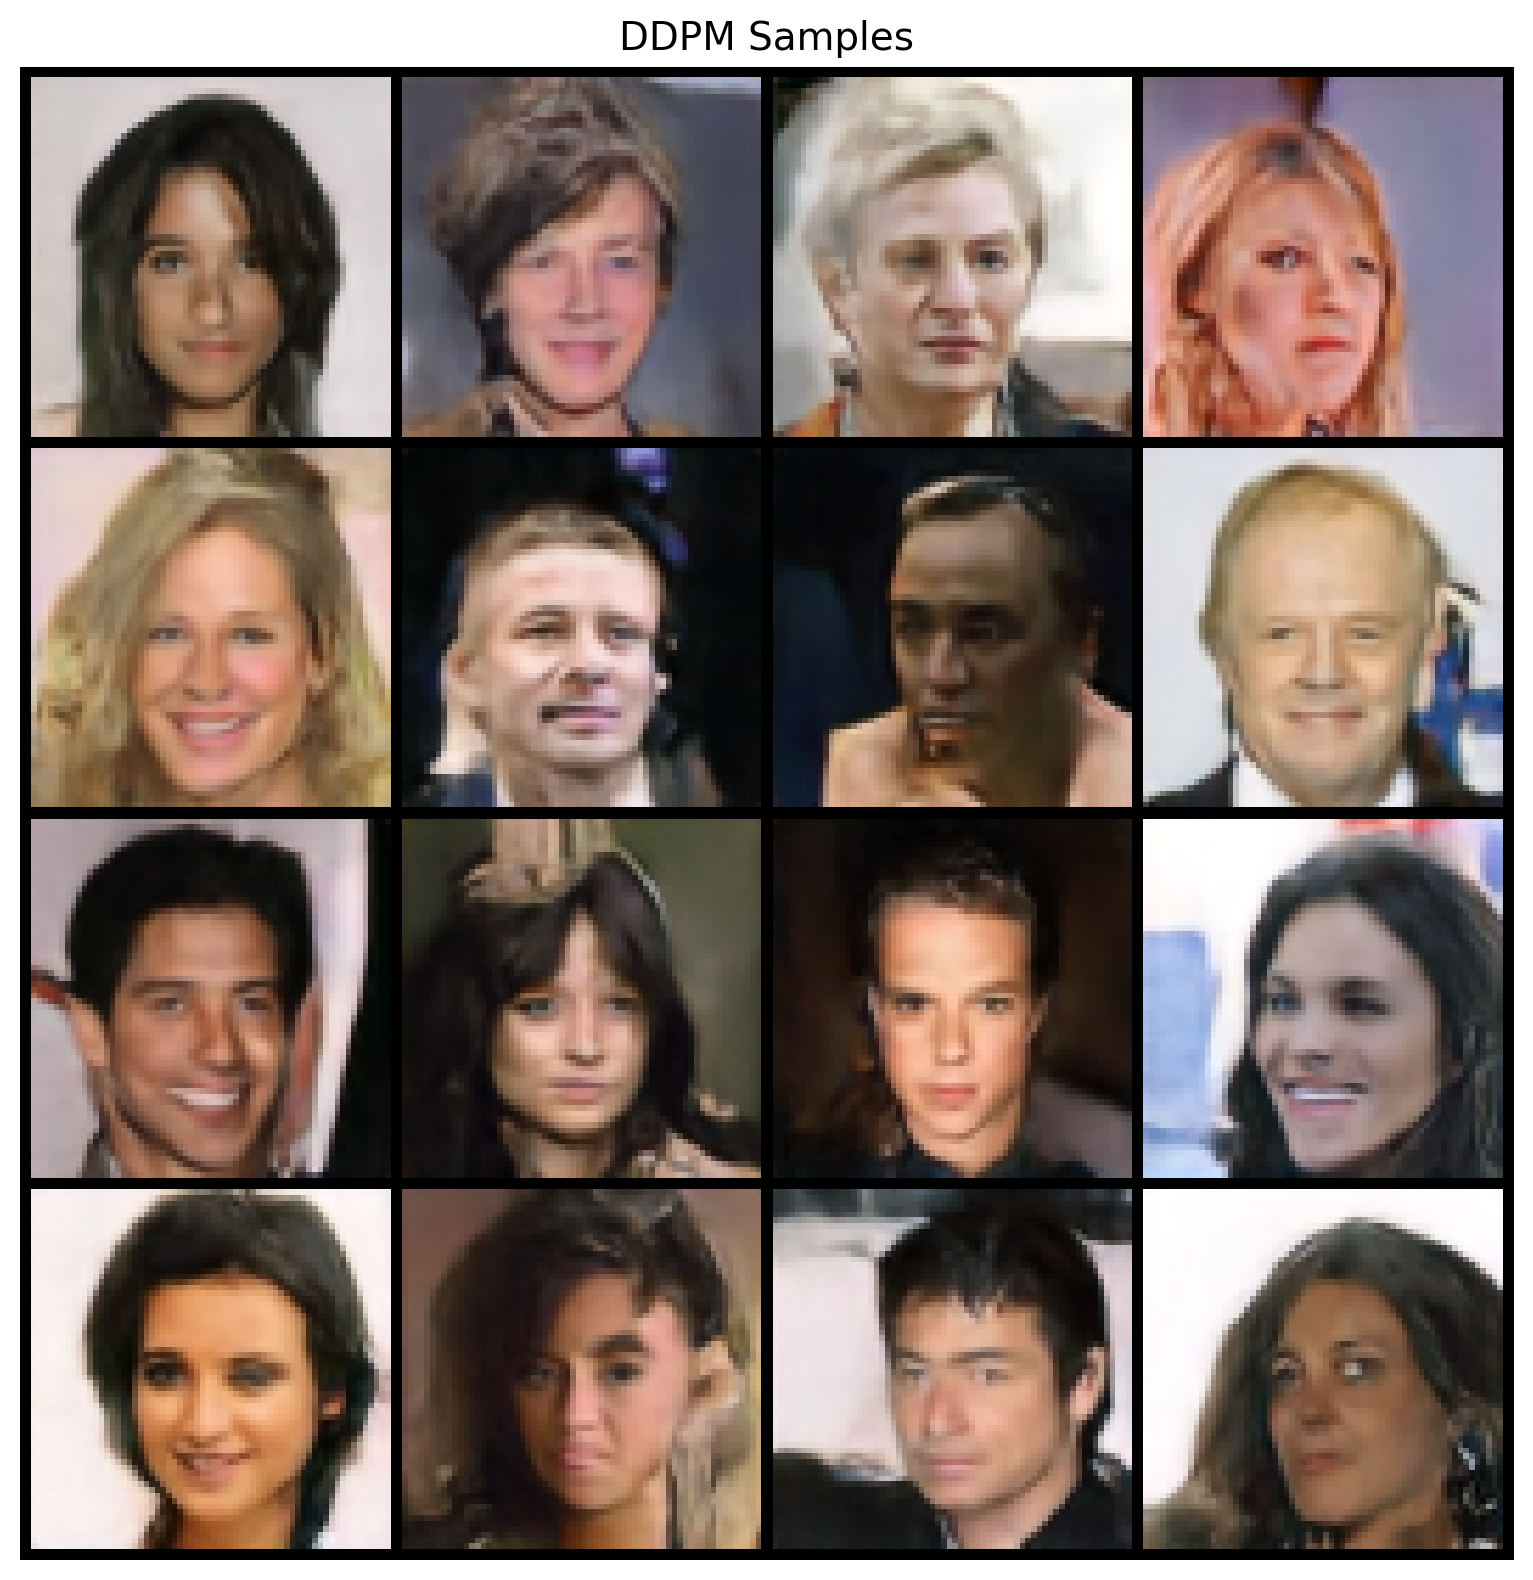

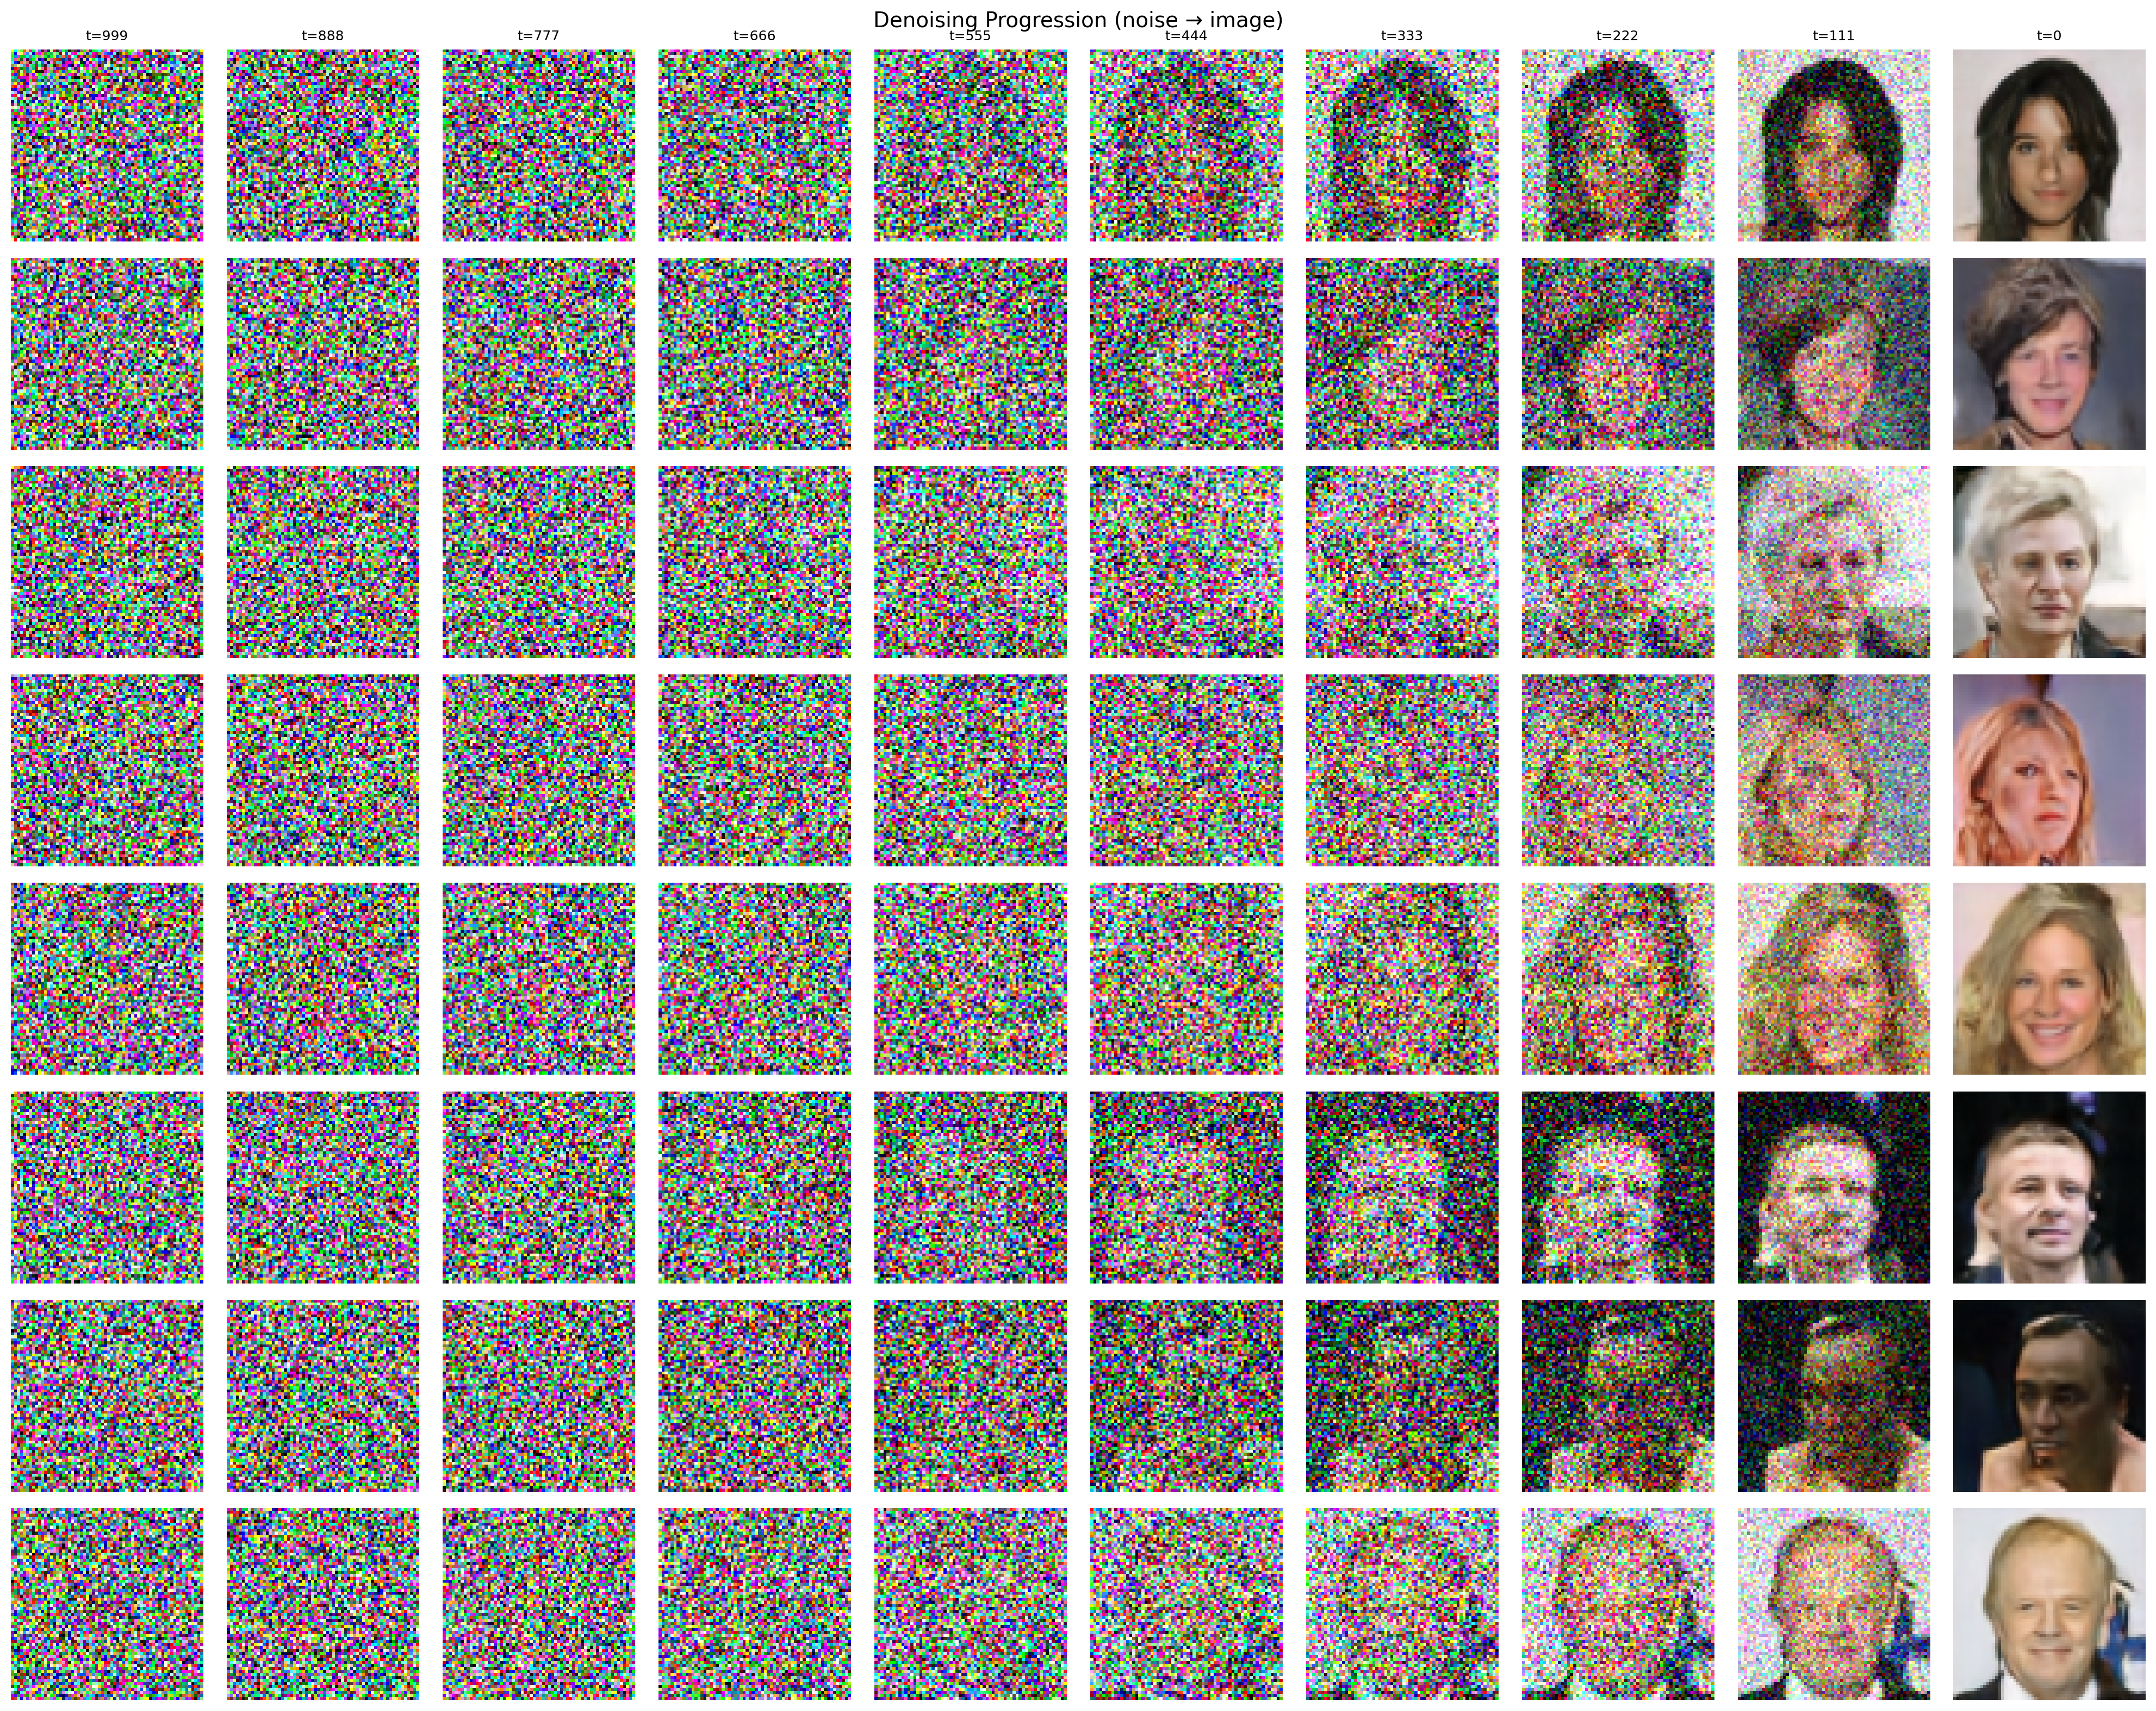

In [5]:
# DDPM Sampling with trajectory tracking
num_samples = 16
image_channels = diffusion.model.in_channels
image_size = 64  # match your training resolution
image_shape = (image_channels, image_size, image_size)

print(f"Sampling with DDPM ({diffusion.num_timesteps} steps)...")
print("This may take a minute...")

# Sample with trajectory: store x_t at each timestep for visualization
with torch.no_grad():
    diffusion.eval_mode()
    x_t = torch.randn(num_samples, *image_shape, device=device)
    trajectory = [x_t.cpu()]

    timesteps = torch.arange(diffusion.num_timesteps - 1, -1, -1)
    for timestep in tqdm(timesteps, desc="Sampling"):
        t = timestep * torch.ones(num_samples, device=device, dtype=torch.long)
        x_t = diffusion.reverse_process(x_t, t)
        trajectory.append(x_t.cpu())

    trajectory = torch.stack(trajectory)  # (T+1, B, C, H, W)
    print(f"Trajectory shape: {trajectory.shape}")

# --- Plot 1: Final samples grid ---
final_samples = trajectory[-1].clamp(-1, 1)
grid = make_grid(final_samples, nrow=4, normalize=True, value_range=(-1, 1), padding=2)
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
ax.imshow(grid.permute(1, 2, 0).numpy())
ax.set_title("DDPM Samples", fontsize=14)
ax.axis('off')
plt.tight_layout()
plt.show()

# --- Plot 2: Denoising progression ---
num_vis = min(8, num_samples)
num_steps_to_show = 10
step_indices = np.linspace(0, len(trajectory) - 1, num_steps_to_show, dtype=int)

fig, axes = plt.subplots(num_vis, num_steps_to_show, figsize=(2 * num_steps_to_show, 2 * num_vis))
for row in range(num_vis):
    for col, step_idx in enumerate(step_indices):
        img = trajectory[step_idx][row].clamp(-1, 1)
        img = (img + 1) / 2  # to [0, 1]
        axes[row, col].imshow(img.permute(1, 2, 0).numpy())
        axes[row, col].axis('off')
        if row == 0:
            t_val = max(0, diffusion.num_timesteps - 1 - step_idx)
            axes[row, col].set_title(f"t={t_val}", fontsize=9)
plt.suptitle("Denoising Progression (noise → image)", fontsize=14)
plt.tight_layout()
plt.show()